# COS60011 Project Demo
## Domain-Adaptive Financial Sentiment Analysis

This notebook implements a clean and consistent experimental pipeline for domain-adaptive financial sentiment analysis.

## 1. Research Framing

This project investigates whether domain adaptation improves sentiment classification performance in financial text.

Research questions:

- RQ1: How does domain shift affect sentiment classification performance?
- RQ2: Does domain-specific training improve performance compared with general-domain training?
- RQ3: Does combining general-domain and financial-domain data improve generalisation?
- RQ4: How does BERT compare with a traditional machine learning baseline?

The main hypothesis is that financial-domain training will improve performance because the model is exposed to specialised financial language. A hybrid model may provide the best balance between general linguistic knowledge and domain-specific learning.

## 2. Environment Setup

This section imports the required libraries and defines general settings used throughout the notebook.

In [ ]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Set a random seed for reproducibility.
RANDOM_STATE = 42

# Define the five final target labels used in this project.
TARGET_LABELS = ["excitement", "panic", "anxiety", "depression", "ambiguity"]

# Define numeric label IDs for machine learning models.
LABEL2ID = {
    "excitement": 0,
    "panic":      1,
    "anxiety":    2,
    "depression": 3,
    "ambiguity":  4
}

# Define reverse mapping from numeric label IDs back to label names.
ID2LABEL = {
    0: "excitement",
    1: "panic",
    2: "anxiety",
    3: "depression",
    4: "ambiguity"
}

## 3. Data Loading

This section loads the raw GoEmotions and StockEmotions files.

Important distinction:

- The three GoEmotions files are partitions of one general-domain dataset, so they are combined.
- The StockEmotions files are already split into train, validation, and test sets, so they remain separate.

In [ ]:
DATA_DIR = Path(".")

# Define file path.
GO_1_PATH = DATA_DIR / "goemotions_1.csv"
GO_2_PATH = DATA_DIR / "goemotions_2.csv"
GO_3_PATH = DATA_DIR / "goemotions_3.csv"

STOCK_TRAIN_PATH = DATA_DIR / "stockemo_train.csv"
STOCK_VAL_PATH = DATA_DIR / "stockemo_val.csv"
STOCK_TEST_PATH = DATA_DIR / "stockemo_test.csv"

# Store all required files in a dictionary for validation.
required_files = {
    "goemotions_1.csv": GO_1_PATH,
    "goemotions_2.csv": GO_2_PATH,
    "goemotions_3.csv": GO_3_PATH,
    "stockemo_train.csv": STOCK_TRAIN_PATH,
    "stockemo_val.csv": STOCK_VAL_PATH,
    "stockemo_test.csv": STOCK_TEST_PATH
}

# Identify missing files before loading data.
missing_files = [name for name, path in required_files.items() if not path.exists()]


# Stop the notebook with a clear message if any file is missing.
if missing_files:
    raise FileNotFoundError(
        "Missing files: " + ", ".join(missing_files) +
        "\nPlease open this notebook from the same folder as your CSV files."
    )

# Load GoEmotion CSV file.
go_1 = pd.read_csv(GO_1_PATH)
go_2 = pd.read_csv(GO_2_PATH)
go_3 = pd.read_csv(GO_3_PATH)

# Combine the three GoEmotions files into one general-domain dataset.
go_all = pd.concat([go_1, go_2, go_3], ignore_index=True)

# Load the StockEmotions splits.
stock_train = pd.read_csv(STOCK_TRAIN_PATH)
stock_val = pd.read_csv(STOCK_VAL_PATH)
stock_test = pd.read_csv(STOCK_TEST_PATH)

# Print dataset shape.
print("Raw GoEmotions:", go_all.shape)
print("Raw StockEmotions train:", stock_train.shape)
print("Raw StockEmotions validation:", stock_val.shape)
print("Raw StockEmotions test:", stock_test.shape)

# Display StockEmotions columns to confirm expected structure.
print("\nStockEmotions columns:", stock_train.columns.tolist())

## 4. Label Mapping

This section maps both datasets into the same five target classes:

- excitement  
- panic  
- anxiety  
- depression  
- ambiguity  

GoEmotions uses many one-hot emotion columns, so it must be converted into a single target label.  
StockEmotions uses `emo_label`, which is mapped directly into the same five-class framework.

Mapped GoEmotions distribution:
target_label
ambiguity     47601
excitement    28246
panic         17625
depression     7045
anxiety         531
Name: count, dtype: int64
Mapped StockEmotions train distribution:
target_label
excitement    2391
ambiguity     1187
anxiety       1099
panic          240
depression     166
Name: count, dtype: int64
Mapped StockEmotions validation distribution:
target_label
excitement    310
ambiguity     146
anxiety       133
panic          33
depression     20
Name: count, dtype: int64
Mapped StockEmotions test distribution:
target_label
excitement    309
ambiguity     147
anxiety       134
panic          31
depression     19
Name: count, dtype: int64


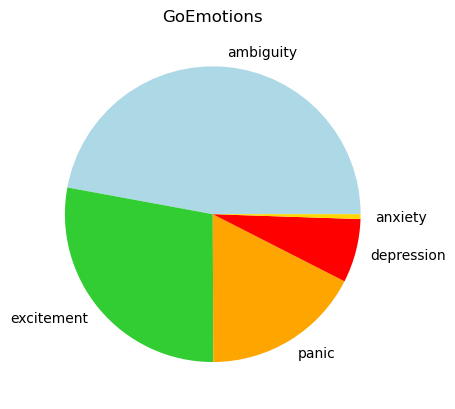

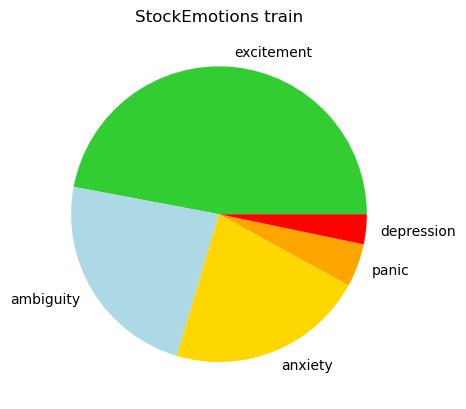

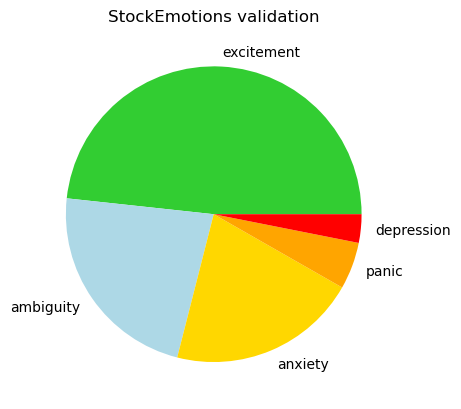

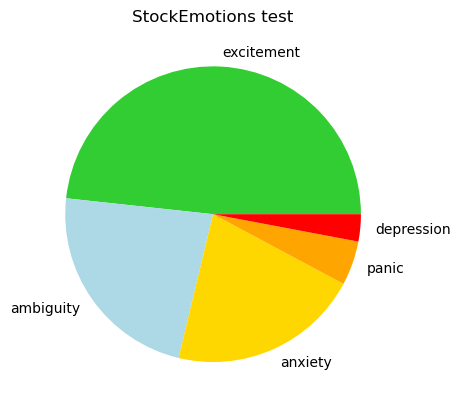

In [29]:
# Define all possible GoEmotions emotion columns.
GO_EMOTION_COLS = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude",
    "grief", "joy", "love", "nervousness", "optimism", "pride",
    "realization", "relief", "remorse", "sadness", "surprise", "neutral"
]

# Keep only GoEmotions columns that exist in the loaded dataset.
GO_EMOTION_COLS = [column for column in GO_EMOTION_COLS if column in go_all.columns]

# Stop if no emotion columns were found.
if len(GO_EMOTION_COLS) == 0:
    raise ValueError("No GoEmotions emotion columns were found. Please check your GoEmotions files.")

# Create a copy of the GoEmotions dataset for mapping.
go_single = go_all.copy()

# Count how many emotion labels are active for each row.
go_single["label_count"] = go_single[GO_EMOTION_COLS].sum(axis=1)

# Keep only single-label rows to avoid ambiguous training targets.
go_single = go_single[go_single["label_count"] == 1].copy()

# Convert one-hot emotion columns into one source emotion label.
go_single["source_emotion"] = go_single[GO_EMOTION_COLS].idxmax(axis=1)

# Define semantic mapping from GoEmotions emotions to the five target classes.
GO_MAP = {
    "joy": "excitement",
    "amusement": "excitement",
    "optimism": "excitement",
    "excitement": "excitement",
    "admiration": "excitement",
    "pride": "excitement",
    "gratitude": "excitement",
    "relief": "excitement",
    "love": "excitement",

    "fear": "panic",
    "anger": "panic",
    "annoyance": "panic",
    "disapproval": "panic",
    "disgust": "panic",

    "nervousness": "anxiety",

    "confusion": "ambiguity",
    "curiosity": "ambiguity",
    "realization": "ambiguity",
    "neutral": "ambiguity",

    "sadness": "depression",
    "grief": "depression",
    "disappointment": "depression",
    "remorse": "depression"
}

# Apply the GoEmotions semantic mapping.
go_single["target_label"] = go_single["source_emotion"].map(GO_MAP)

# Remove rows that cannot be mapped into the five-class framework.
go_df = go_single.dropna(subset=["target_label"]).copy()

# Keep only text and target label.
go_df = go_df[["text", "target_label"]].copy()


# Define a function to map StockEmotions labels into the five target labels.
def map_stock_label(label):
    # Convert the raw label into lowercase text.
    clean_label = str(label).strip().lower()

    # Define direct mapping from StockEmotions labels to project labels.
    stock_map = {
        "excitement": "excitement",
        "excited": "excitement",
        "optimism": "excitement",
        "optimistic": "excitement",

        "panic": "panic",
        "fear": "panic",

        "anxiety": "anxiety",
        "anxious": "anxiety",
        "worry": "anxiety",
        "worried": "anxiety",

        "ambiguity": "ambiguity",
        "ambiguous": "ambiguity",
        "neutral": "ambiguity",
        "confusion": "ambiguity",

        "depression": "depression",
        "depressed": "depression",
        "sadness": "depression",
        "sad": "depression"
    }

    # Return mapped label if it exists, otherwise return NaN.
    return stock_map.get(clean_label, np.nan)

# Define a helper function to prepare a StockEmotions split.
def prepare_stock_split(df, split_name):
    # Create a copy to avoid modifying the original split.
    prepared = df.copy()

    # Check that the processed text column exists.
    if "processed" not in prepared.columns:
        raise KeyError(f"{split_name} does not contain a 'processed' column.")

    # Check that the emotion label column exists.
    if "emo_label" not in prepared.columns:
        raise KeyError(f"{split_name} does not contain an 'emo_label' column.")

    # Map raw emotion labels to the five target labels.
    prepared["target_label"] = prepared["emo_label"].apply(map_stock_label)

    # Remove labels outside the five-class framework.
    prepared = prepared.dropna(subset=["target_label"]).copy()

    # Keep only processed text and target label.
    prepared = prepared[["processed", "target_label"]].rename(columns={"processed": "text"})

    # Reset the row index.
    prepared = prepared.reset_index(drop=True)

    # Return the prepared split.
    return prepared

# Prepare the mapped StockEmotions split.
stock_train_m = prepare_stock_split(stock_train, "StockEmotions train")
stock_val_m = prepare_stock_split(stock_val, "StockEmotions validation")
stock_test_m = prepare_stock_split(stock_test, "StockEmotions test")

# Add numeric labels to GoEmotions.
go_df["label"] = go_df["target_label"].map(LABEL2ID).astype(int)

# Add numeric labels to StockEmotions data.
stock_train_m["label"] = stock_train_m["target_label"].map(LABEL2ID).astype(int)
stock_val_m["label"] = stock_val_m["target_label"].map(LABEL2ID).astype(int)
stock_test_m["label"] = stock_test_m["target_label"].map(LABEL2ID).astype(int)

# declare the colour map for the blue (changes per plot)
pie_colours_map = {
    "excitement":"limegreen",
    "panic":"orange",
    "anxiety":"gold",
    "ambiguity":"lightblue",
    "depression": "red"
}

def plot_map(data, comment):
    # get column stats
    counts = data["target_label"].value_counts()

    # print stats
    print(f"Mapped {comment} distribution:")
    print(data["target_label"].value_counts())

    plt.figure() # start a new subplot
    # create a new pie chart represented by the counts in the stats, labelled by the names of the labels, coloured by the colours mapped to the list of labels for the plot
    plt.pie([i / len(data) for i in list(counts.values)],
            labels=list(counts.keys()),
            colors=[pie_colours_map[i] for i in list(counts.keys())])     # https://stackoverflow.com/questions/62359875/keep-same-color-for-each-label-in-different-pie-charts
    plt.title(comment) # title the plot
    plt.plot() # plot

# Print mapped GoEmotions class distribution and class counts
plot_map(go_df,"GoEmotions")

# Print mapped StockEmotions class distribution and class counts
plot_map(stock_train_m,"StockEmotions train")
plot_map(stock_val_m,"StockEmotions validation")
plot_map(stock_test_m,"StockEmotions test")


## 5. Text Cleaning

This section performs conservative cleaning.

BERT can understand context, so aggressive cleaning is avoided. The goal is only to remove noise such as URLs, mentions, ticker symbols, and repeated spaces.

In [ ]:
# Define a conservative text cleaning function for financial and general comments.
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # Remove URLs
    text = re.sub(r"@\w+", " ", text)             # Remove user mentions
    text = re.sub(r"#\w+", " ", text)             # Remove hashtags
    text = re.sub(r"\$[a-zA-Z]+", " ", text)      # Remove ticker symbols
    text = re.sub(r"[^a-z0-9\s!?.,]", " ", text)  # Keep letters, digits, spaces, and basic punctuation useful for sentiment tone.
    text = re.sub(r"[^\w\s\[\]'!?.,]", " ", text) # Remove special chars
    text = re.sub(r"\s+", " ", text)              # Replace repeated spaces with a single space.
    text = text.strip()                           # Remove leading and trailing whitespace.
    return text

# Apply cleaning to the mapped GoEmotions and StockEmotions dataframe.
go_df["clean_text"] = go_df["text"].apply(clean_text)
stock_train_m["clean_text"] = stock_train_m["text"].apply(clean_text)
stock_val_m["clean_text"] = stock_val_m["text"].apply(clean_text)
stock_test_m["clean_text"] = stock_test_m["text"].apply(clean_text)

# Remove GoEmotions and StockEmotions rows that became empty after cleaning.
go_df = go_df[go_df["clean_text"].str.len() > 0].reset_index(drop=True)
stock_train_m = stock_train_m[stock_train_m["clean_text"].str.len() > 0].reset_index(drop=True)
stock_val_m = stock_val_m[stock_val_m["clean_text"].str.len() > 0].reset_index(drop=True)
stock_test_m = stock_test_m[stock_test_m["clean_text"].str.len() > 0].reset_index(drop=True)

# Display sample cleaned rows to support transparent preprocessing.
display(go_df[["text", "clean_text", "target_label"]].head()) # needs work
display(stock_train_m[["text", "clean_text", "target_label"]].head())

,text,clean_text,target_label
0,That game hurt.,that game hurt.,depression
1,"You do right, if you don't care then fuck 'em!","you do right, if you don t care then fuck em!",ambiguity
2,Man I love reddit.,man i love reddit.,excitement
3,"[NAME] was nowhere near them, he was by the Fa...","name was nowhere near them, he was by the falcon.",ambiguity
4,Right? Considering it’s such an important docu...,right? considering it s such an important docu...,excitement


,text,clean_text,target_label
0,Amazon Dow futures up by 100 points already [...,amazon dow futures up by 100 points already pa...,excitement
1,Tesla Daddy's drinkin' eArly tonight! Here's t...,tesla daddy s drinkin early tonight! here s to...,excitement
2,Apple We’ll been riding since last December fr...,apple we ll been riding since last december fr...,ambiguity
3,"Tesla happy new year, 2020, everyone [wine gla...","tesla happy new year, 2020, everyone wine glas...",excitement
4,"Tesla haha just a collection of greats...""Mars...",tesla haha just a collection of greats... mars...,excitement
